<a href="https://colab.research.google.com/github/sisi-y/100-Days-ML-Journey/blob/main/kenya_random_forest_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
print("Done")

Done


In [6]:
np.random.seed(42)
n = 200

data = {
    'distance_km': np.random.uniform(0.5, 25, n).round(1),
    'days_missed': np.random.randint(0, 30, n),
    'avg_score': np.random.uniform(20, 95, n).round(1),
    'family_income': np.random.randint(3000, 80000, n),
    'siblings_in_school': np.random.randint(0, 5, n),
}

df = pd.DataFrame(data)
df['dropped_out'] = (
    (df['family_income'] < 10000) &
    (df['days_missed'] > 15) |
    (df['distance_km'] > 15) &
    (df['avg_score'] < 40)
).astype(int)

print(f"Total students: {len(df)}")
print(f"Dropped out: {df['dropped_out'].sum()}")
print(df.head())

Total students: 200
Dropped out: 31
   distance_km  days_missed  avg_score  family_income  siblings_in_school  \
0          9.7           23       52.9          53990                   2   
1         23.8           19       25.9          78672                   2   
2         18.4           10       21.9          68545                   4   
3         15.2           16       92.2          61141                   3   
4          4.3            7       82.7          26793                   1   

   dropped_out  
0            0  
1            1  
2            1  
3            0  
4            0  


In [7]:
features = ['distance_km', 'days_missed', 'avg_score',
            'family_income', 'siblings_in_school']
X = df[features]
y = df['dropped_out']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
rf_model = RandomForestClassifier(
    n_estimators=100,   # How many trees to build
    max_depth=5,        # Max depth of each tree
    random_state=42    # Reproducible results
)
rf_model.fit(X_train, y_train)
print("✅ Random Forest trained — 100 trees built!")

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy: {accuracy * 100:.1f}%")
print(classification_report(y_test, y_pred))

✅ Random Forest trained — 100 trees built!
🎯 Accuracy: 92.5%
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        35
           1       1.00      0.40      0.57         5

    accuracy                           0.93        40
   macro avg       0.96      0.70      0.77        40
weighted avg       0.93      0.93      0.91        40




📊 Most important factors for dropout prediction:
              feature  importance
2           avg_score    0.345198
3       family_income    0.263632
0         distance_km    0.250860
1         days_missed    0.107820
4  siblings_in_school    0.032491


/tmp/ipykernel_534/3052430258.py:16: UserWarning: Glyph 127472 (\N{REGIONAL INDICATOR SYMBOL LETTER K}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/3052430258.py:16: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127472 (\N{REGIONAL INDICATOR SYMBOL LETTER K}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


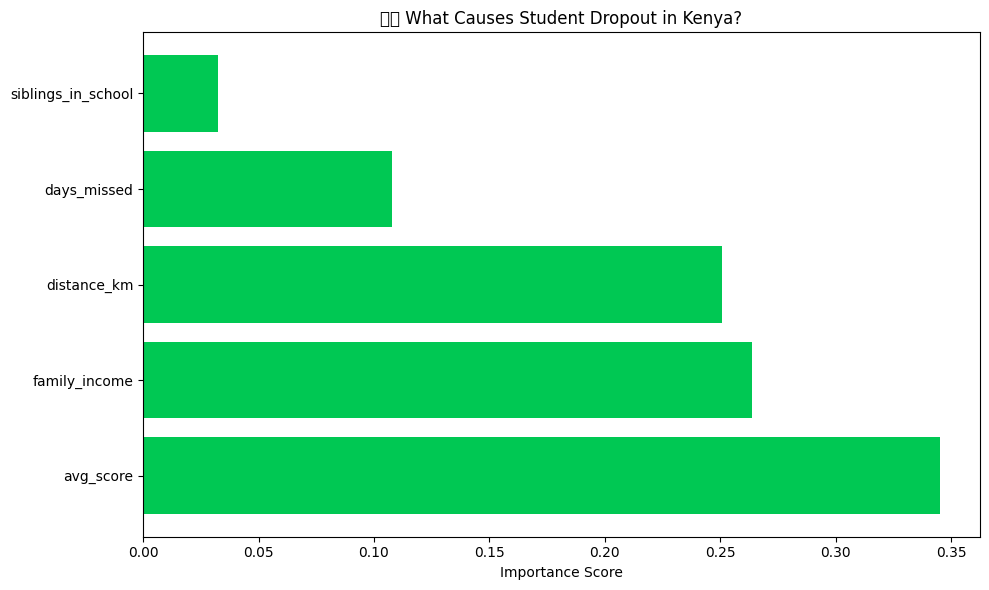

In [8]:
importance = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values('importance', ascending=False)

print("\n📊 Most important factors for dropout prediction:")
print(importance_df)

# Chart it
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'],
        color='#00c853')
plt.xlabel('Importance Score')
plt.title('🇰🇪 What Causes Student Dropout in Kenya?')
plt.tight_layout()
plt.show()


 Most important factors for dropout prediction:
              feature  importance
2           avg_score    0.345198
3       family_income    0.263632
0         distance_km    0.250860
1         days_missed    0.107820
4  siblings_in_school    0.032491

📊 Most important factors for dropout prediction:
              feature  importance
2           avg_score    0.345198
3       family_income    0.263632
0         distance_km    0.250860
1         days_missed    0.107820
4  siblings_in_school    0.032491


/tmp/ipykernel_534/214857294.py:17: UserWarning: Glyph 127472 (\N{REGIONAL INDICATOR SYMBOL LETTER K}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_534/214857294.py:17: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127472 (\N{REGIONAL INDICATOR SYMBOL LETTER K}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127466 (\N{REGIONAL INDICATOR SYMBOL LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


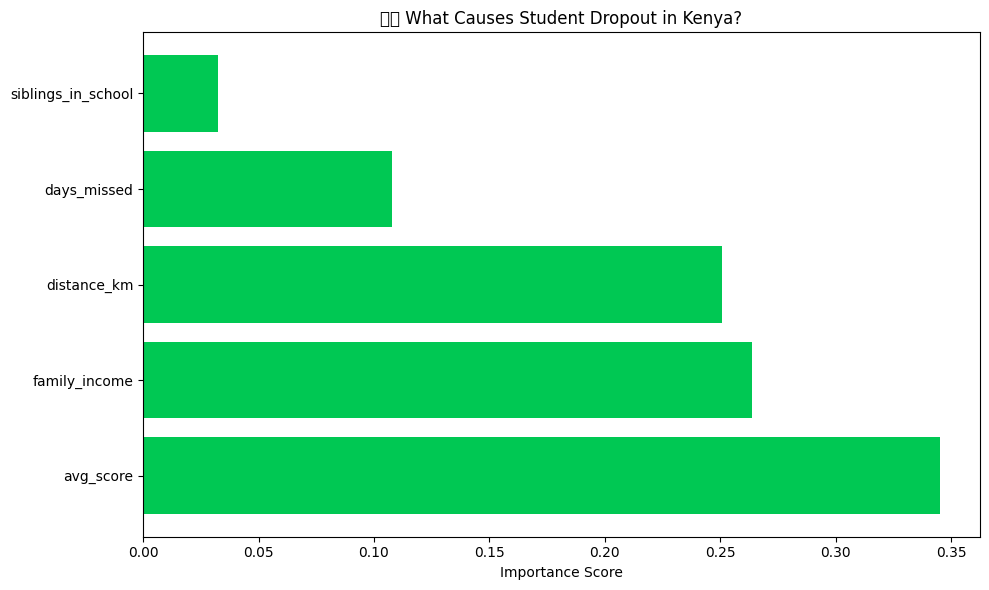

In [9]:
importance = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': features,
    'importance': importance
}).sort_values('importance', ascending=False)
print("\n Most important factors for dropout prediction:")
print(importance_df)
plt.figure(figsize=(10, 6))


print("\n📊 Most important factors for dropout prediction:")
print(importance_df)
plt.barh(importance_df['feature'], importance_df['importance'],
        color='#00c853')
plt.xlabel('Importance Score')
plt.title('🇰🇪 What Causes Student Dropout in Kenya?')
plt.tight_layout()
plt.show()

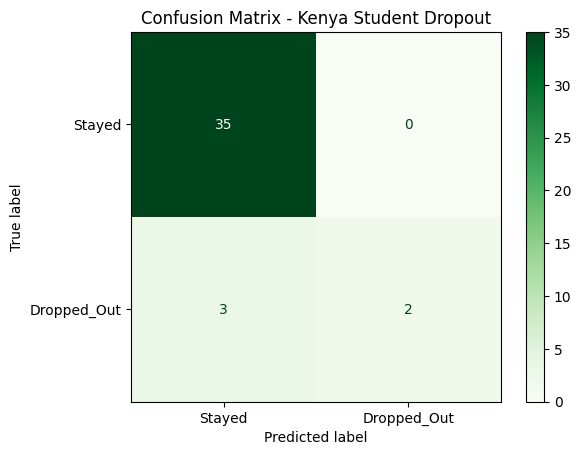

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Stayed', 'Dropped_Out'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix - Kenya Student Dropout')
plt.show()